<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E7%89%B9%E5%BE%B5%E7%AF%A9%E9%81%B8%E5%BE%8C%E5%BB%BA%E6%A8%A1Y3_%E4%B8%8D%E8%A6%81%E4%BD%BF%E7%94%A8DeSOx_2nd%E4%BD%9C%E7%82%BA%E7%89%B9%E5%BE%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import joblib
features = joblib.load('/content/Y3特徵.pkl')
features = list(set(features) - set(['DeSOx_2nd']))
features

['MLUT4_ZT-231',
 'MLUT4_AT-237',
 'MLUT4_FT-232',
 'MLUT4_FIC-231C',
 'MLUT4_AIA792101A',
 'MLUT4_FT-957',
 'MLUT4_FT-792020',
 'DeSOx_1st',
 '鈣硫比',
 'MLUT4_FIC-231A',
 'MLUT4_FIC-231B',
 'MLUT4_TE-252D',
 'MLUT4_PIC-233',
 'MLUT4_IT-E7925A',
 'MLUT4_FT-956',
 'MLUT4_PDT-231',
 'MLUT4_SIV-B7921',
 'MLUT4_FQ-205',
 'MLUT4_FT-V004',
 'MLUT4_FT-951AB',
 'MLUT4_PDT-232',
 'MLUT4_FIC-233',
 'MLUT4_AIA792101B',
 'MLUT4_TE-251I']

In [29]:
from google.colab import drive
import numpy as np
drive.mount('/content/drive')
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'
for i in df.columns:
  df[i] = pd.to_numeric(df[i], errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan)
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AIC-232B,MLUT4_AT-232A,MLUT4_AT-237,MLUT4_AT-240,MLUT4_AT-240A,MLUT4_FIC-231A,MLUT4_FIC-231B,MLUT4_FIC-231C,...,MLUT4_TE-252F,MLUT4_TE-252G,MLUT4_TE-252H,MLUT4_TE-252I,MLUT4_ZT-231,MLUT4_ZT-232,DeSOx_1st,DeSOx_2nd,前爐SOx濃度,鈣硫比
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,5.540932,6.800000,67.034424,151.208024,9.623605,8.619934,8.619934,20.605973,0.000000,17.456094,...,876.984866,845.297084,845.703201,876.997523,59.200001,15.000000,0.969941,0.871410,2230.093232,2.223152
2024-01-01 00:05:00,5.533478,6.800000,66.662524,150.811453,9.616252,8.147002,8.147002,20.181020,0.000000,17.449118,...,875.326466,846.587071,844.102850,877.381060,59.200001,15.000000,0.969979,0.877787,2220.527929,2.220789
2024-01-01 00:10:00,5.526025,6.800000,64.320729,151.708113,9.608899,8.247992,8.247992,20.200619,0.000000,17.442142,...,875.675699,845.374599,843.500123,877.897600,59.200001,15.000000,0.971249,0.871768,2237.129686,2.217612
2024-01-01 00:15:00,5.518571,6.801543,64.840762,151.283528,9.600898,7.605820,7.605820,20.220218,0.000000,17.571883,...,875.435828,845.100450,842.910508,874.888616,59.200001,15.000000,0.970896,0.882700,2227.895501,2.214444
2024-01-01 00:20:00,5.511117,6.819977,64.390831,150.994896,9.581994,6.110485,6.110485,20.549012,0.000000,17.339679,...,875.245400,846.058978,844.200021,878.416710,59.200001,15.000000,0.970878,0.905103,2211.052236,2.211285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,6.258452,5.140339,114.166438,209.520746,9.360355,13.105704,13.105704,12.795748,11.854892,12.842200,...,916.635699,889.885541,906.016252,870.865216,100.000000,26.103367,0.945172,0.885205,2082.274527,3.928554
2024-09-15 23:40:00,6.284992,5.166336,106.669841,208.177318,9.280099,9.903673,9.903673,12.797045,11.862273,12.823741,...,914.065610,889.042164,904.255862,869.007829,100.000000,26.093265,0.948517,0.907156,2071.948976,3.927730
2024-09-15 23:45:00,6.232171,5.225976,104.663595,211.564232,9.359701,9.345572,9.345572,12.798342,11.880556,12.842696,...,913.978871,890.439554,903.442876,867.712970,100.000000,26.100000,0.949882,0.910708,2088.339754,3.928170


In [30]:
y_col = ['前爐SOx濃度']

In [31]:
df[features+y_col]

,MLUT4_ZT-231,MLUT4_AT-237,MLUT4_FT-232,MLUT4_FIC-231C,MLUT4_AIA792101A,MLUT4_FT-957,MLUT4_FT-792020,DeSOx_1st,鈣硫比,MLUT4_FIC-231A,...,MLUT4_PDT-231,MLUT4_SIV-B7921,MLUT4_FQ-205,MLUT4_FT-V004,MLUT4_FT-951AB,MLUT4_PDT-232,MLUT4_FIC-233,MLUT4_AIA792101B,MLUT4_TE-251I,前爐SOx濃度
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,59.200001,9.623605,359.664266,17.456094,5.540932,3917.594740,17600.761361,0.969941,2.223152,20.605973,...,1215.689879,NaN,357.373726,0.00,99.231466,78.370626,179.388400,6.800000,879.426597,2230.093232
2024-01-01 00:05:00,59.200001,9.616252,359.556551,17.449118,5.533478,3917.320459,17593.312001,0.969979,2.220789,20.181020,...,1212.892826,NaN,356.975651,0.00,100.033768,79.258313,179.313536,6.800000,879.618450,2220.527929
2024-01-01 00:10:00,59.200001,9.608899,355.172410,17.442142,5.526025,3913.623750,17600.111236,0.971249,2.217612,20.200619,...,1214.262849,NaN,355.650485,0.00,99.932670,77.719304,179.519411,6.800000,879.743974,2237.129686
2024-01-01 00:15:00,59.200001,9.600898,355.875036,17.571883,5.518571,3929.257511,17603.981252,0.970896,2.214444,20.220218,...,1214.015649,NaN,356.219519,0.00,99.831572,78.297800,179.465741,6.801543,877.116412,2227.895501
2024-01-01 00:20:00,59.200001,9.581994,356.333792,17.339679,5.511117,3914.198450,17602.871415,0.970878,2.211285,20.549012,...,1212.987176,NaN,357.409226,0.00,100.181768,78.501901,179.344261,6.819977,880.023843,2211.052236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,100.000000,9.360355,243.293496,12.842200,6.258452,2639.985169,6494.025118,0.945172,3.928554,12.795748,...,1178.392784,1560.849374,307.745677,1.87,97.405392,55.084016,227.094066,5.140339,884.959304,2082.274527
2024-09-15 23:40:00,100.000000,9.280099,241.649951,12.823741,6.284992,2644.140047,6471.585576,0.948517,3.927730,12.797045,...,1178.695717,1560.692594,308.234169,1.87,97.528753,54.970461,226.873818,5.166336,884.103627,2071.948976
2024-09-15 23:45:00,100.000000,9.359701,244.585288,12.842696,6.232171,2636.322947,6478.218888,0.949882,3.928170,12.798342,...,1180.822529,1560.862653,304.988863,1.87,98.286113,54.838819,227.212922,5.225976,883.118773,2088.339754


# 刪除離群值

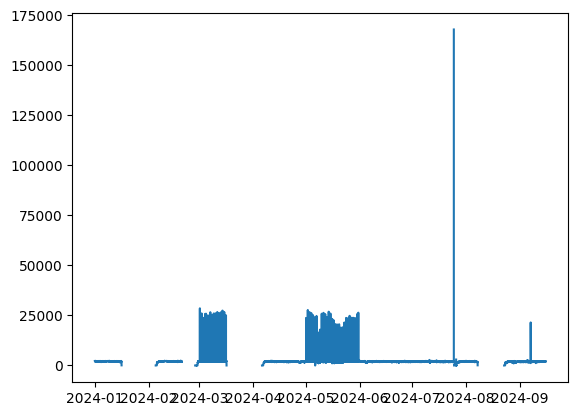

In [32]:
import matplotlib.pyplot as plt
plt.plot(df.index,df['前爐SOx濃度'])
plt.show()

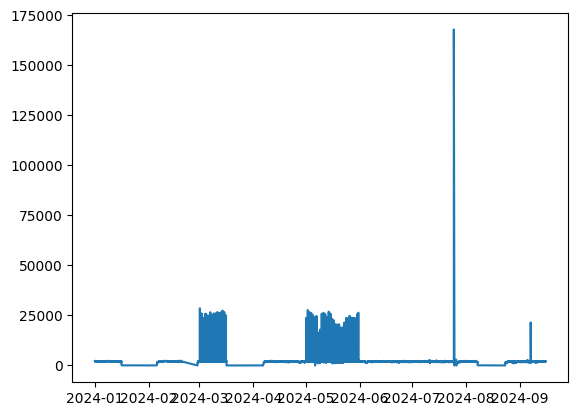

In [33]:
data = df[df['前爐SOx濃度']>0]
data = data[features+y_col]
plt.plot(data.index,data['前爐SOx濃度'])
plt.show()

# 馬氏距離刪除離群值

In [34]:
import pandas as pd
import numpy as np
from scipy.stats import chi2

def del_outliers_mahalanobis(df):
  mean_vec = df.mean().values
  cov_matrix = np.cov(df.values, rowvar=False)
  inv_cov_matrix = np.linalg.inv(cov_matrix)

  # Step 2: 計算每筆資料的馬氏距離
  def mahalanobis(x, mean, inv_cov):
      diff = x - mean
      return np.sqrt(diff.T @ inv_cov @ diff)

  # 計算所有樣本的距離
  distances = df.apply(lambda row: mahalanobis(row.values, mean_vec, inv_cov_matrix), axis=1)

  # Step 3: 決定閾值，例如卡方分布下95%置信區間的臨界值（自由度=2因為是兩欄）
  threshold = np.sqrt(chi2.ppf(0.99, df=2))

  # Step 4: 過濾掉離群樣本
  df_clean = df[distances < threshold]

  # 如果你想看哪些是離群值
  outliers = df[distances >= threshold]

  return df_clean

In [35]:
data = data.dropna(axis=1)
data.shape

(55461, 24)

In [36]:
data.isnull().sum().sum()

np.int64(0)

In [37]:
features = list(set(features)&set(data.columns))
features

['MLUT4_ZT-231',
 'MLUT4_AT-237',
 'MLUT4_FIC-231C',
 'MLUT4_FT-792020',
 'MLUT4_FIC-231B',
 'MLUT4_TE-252D',
 'MLUT4_FT-951AB',
 'MLUT4_PDT-232',
 'MLUT4_TE-251I',
 'MLUT4_FT-232',
 'MLUT4_AIA792101A',
 'MLUT4_FT-957',
 'DeSOx_1st',
 '鈣硫比',
 'MLUT4_FIC-231A',
 'MLUT4_PIC-233',
 'MLUT4_IT-E7925A',
 'MLUT4_FT-956',
 'MLUT4_PDT-231',
 'MLUT4_FQ-205',
 'MLUT4_FT-V004',
 'MLUT4_FIC-233',
 'MLUT4_AIA792101B']

MLUT4_ZT-231


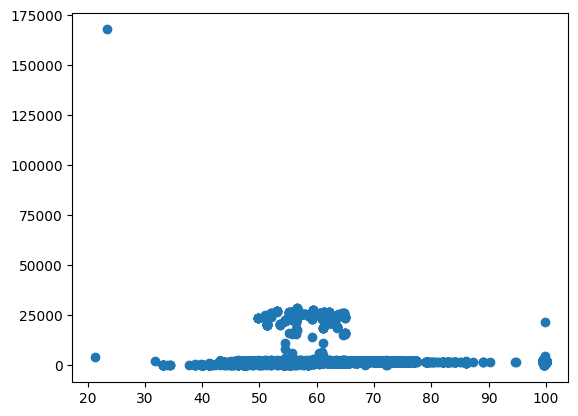

MLUT4_AT-237


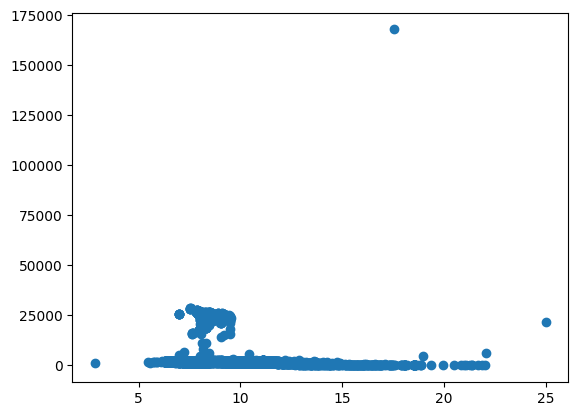

MLUT4_FIC-231C


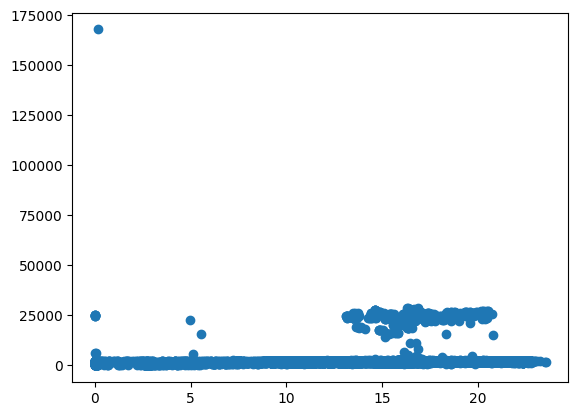

MLUT4_FT-792020


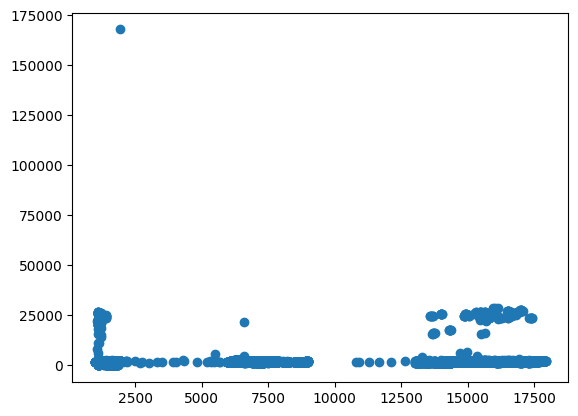

MLUT4_FIC-231B


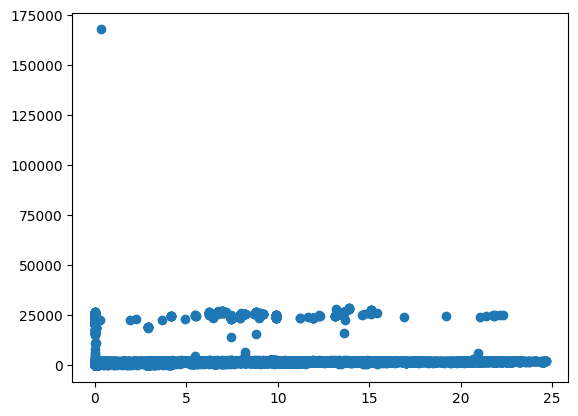

MLUT4_TE-252D


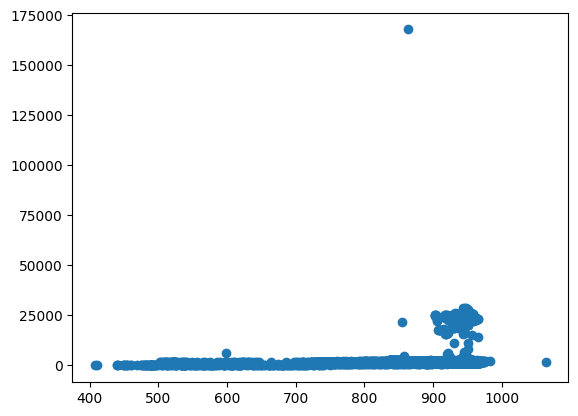

MLUT4_FT-951AB


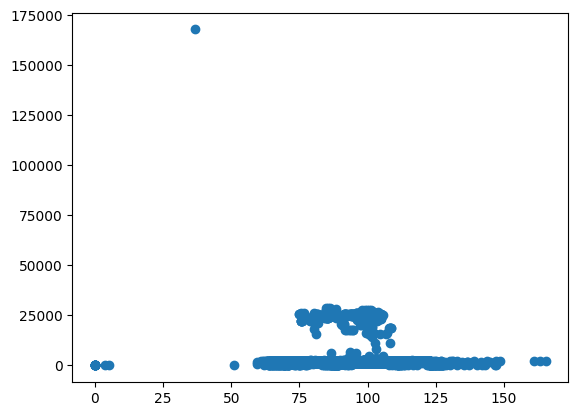

MLUT4_PDT-232


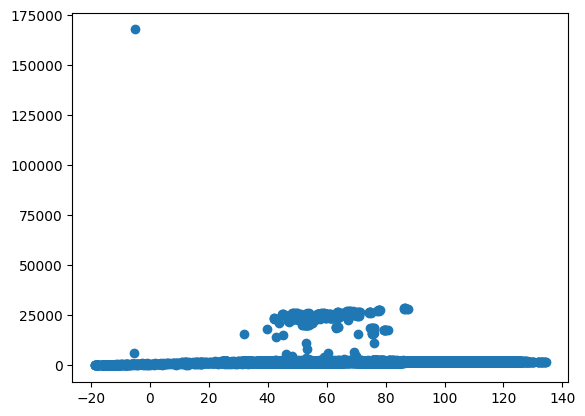

MLUT4_TE-251I


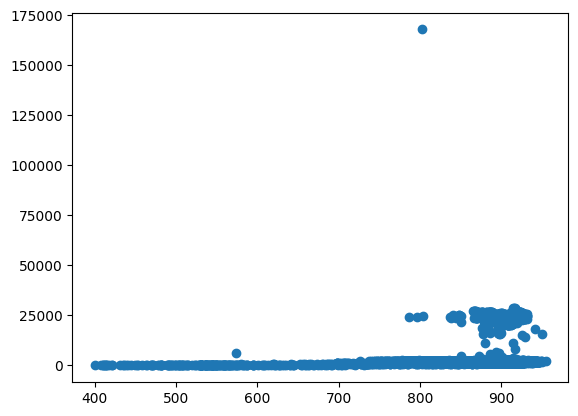

MLUT4_FT-232


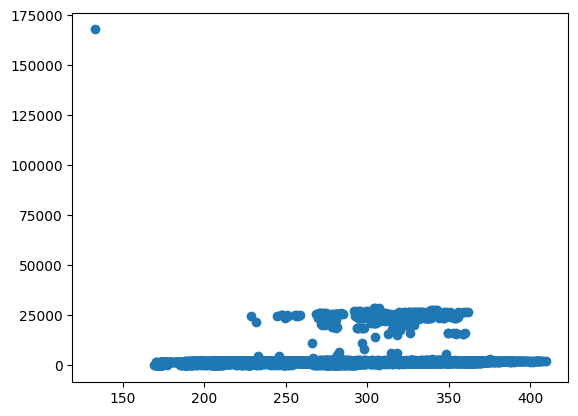

MLUT4_AIA792101A


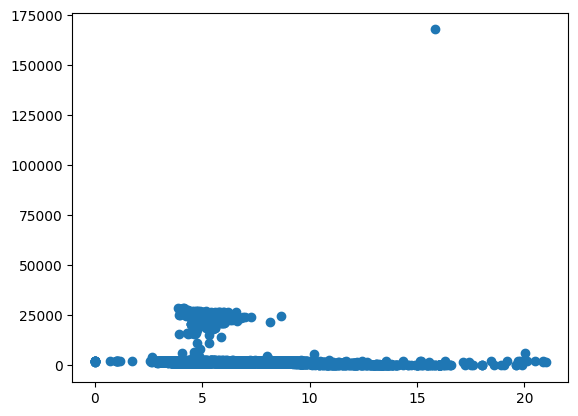

MLUT4_FT-957


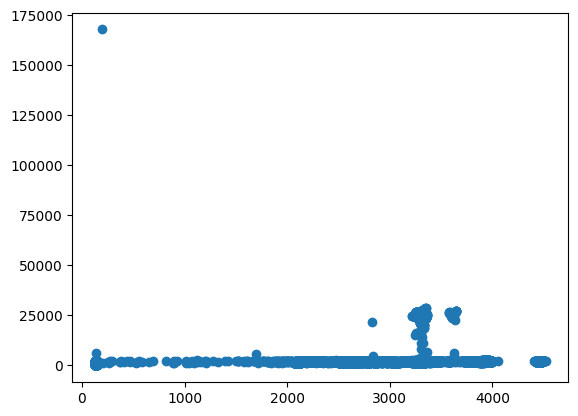

DeSOx_1st


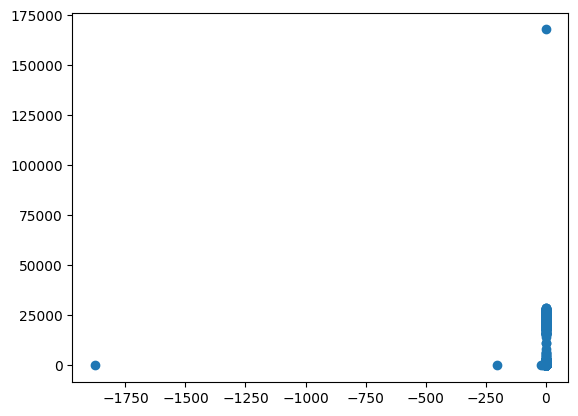

鈣硫比


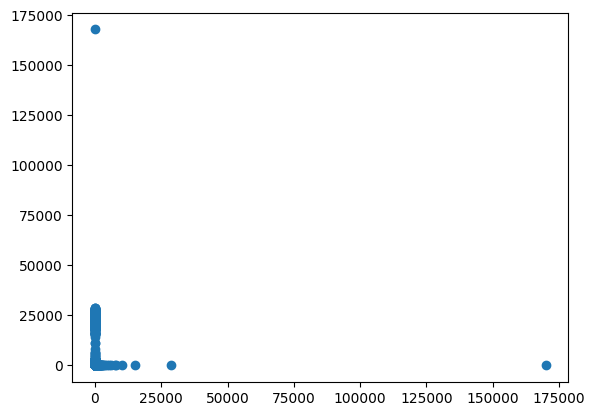

MLUT4_FIC-231A


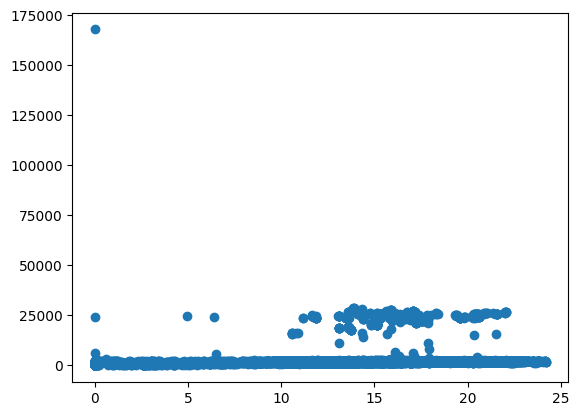

MLUT4_PIC-233


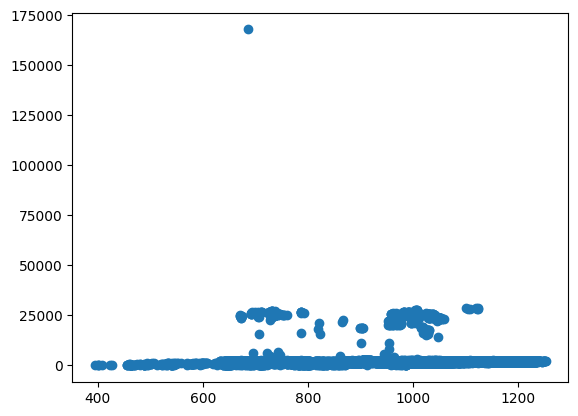

MLUT4_IT-E7925A


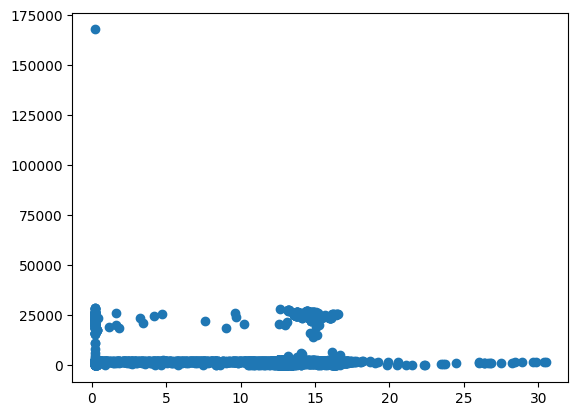

MLUT4_FT-956


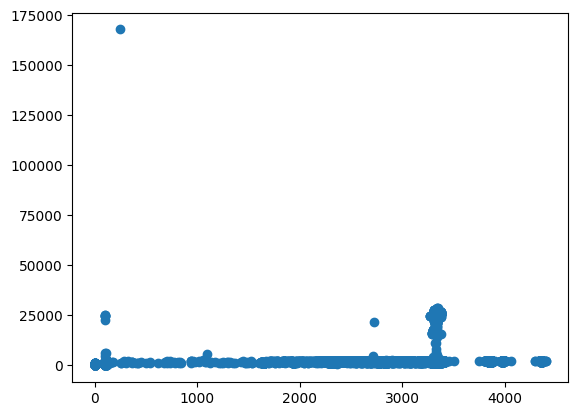

MLUT4_PDT-231


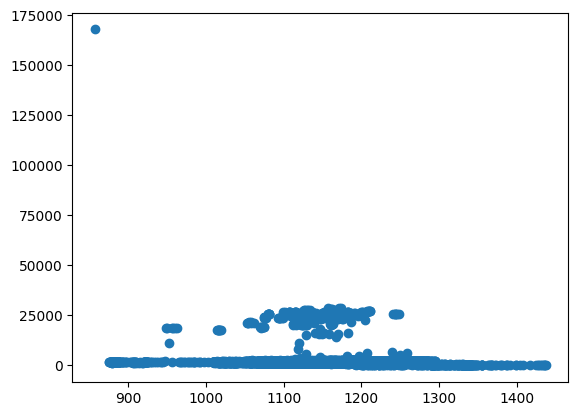

MLUT4_FQ-205


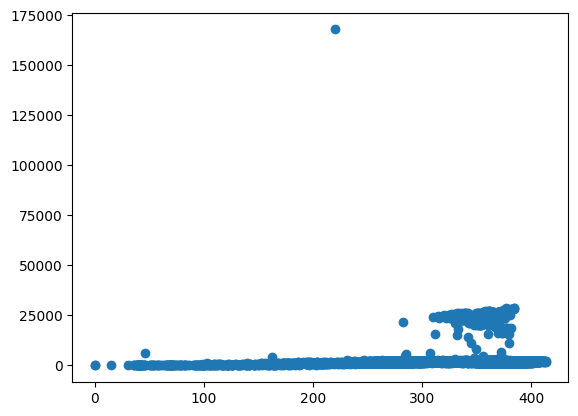

MLUT4_FT-V004


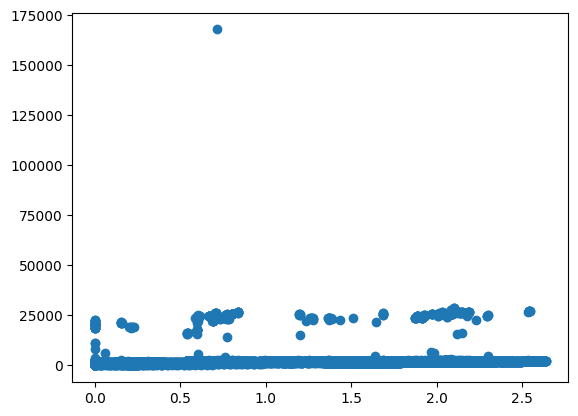

MLUT4_FIC-233


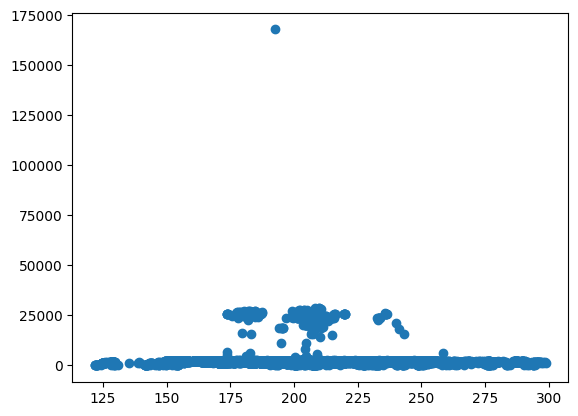

MLUT4_AIA792101B


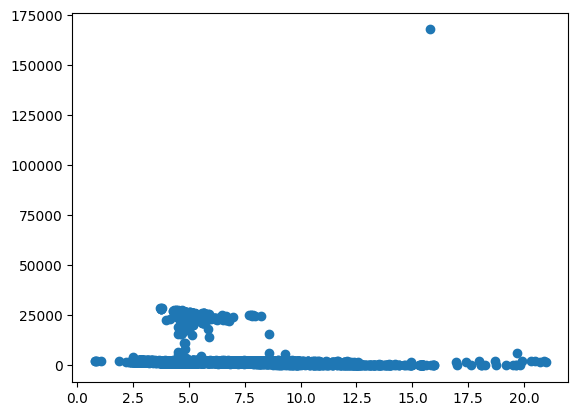

In [38]:
for i in features:
  plt.scatter(data[i],data['前爐SOx濃度'])
  print(i)
  plt.show()

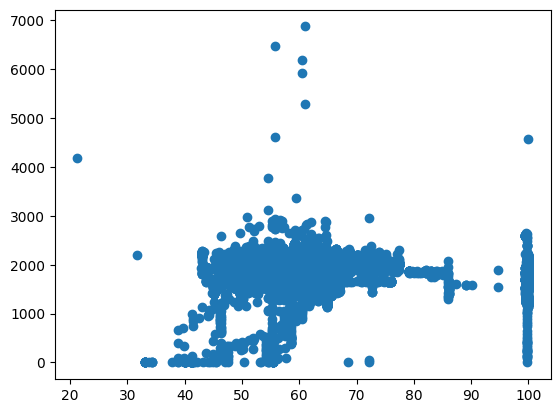

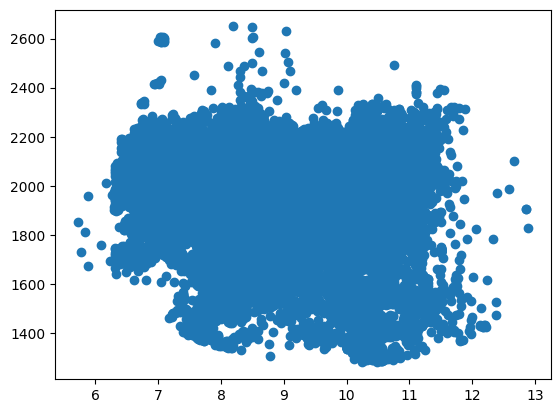

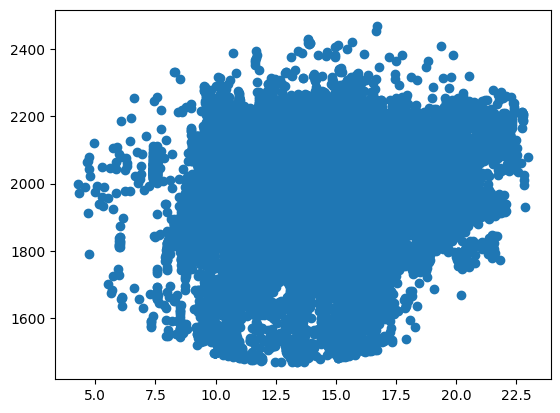

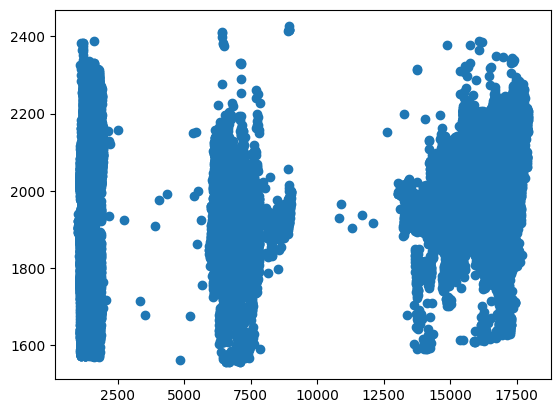

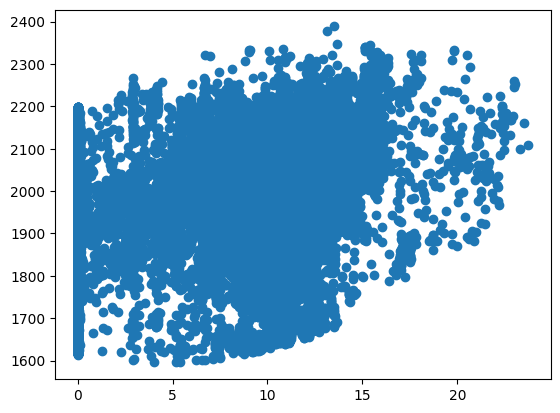

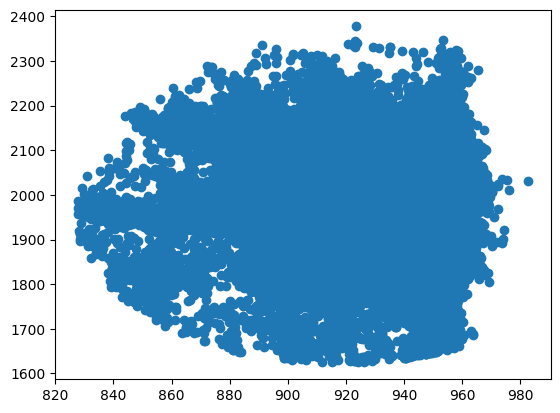

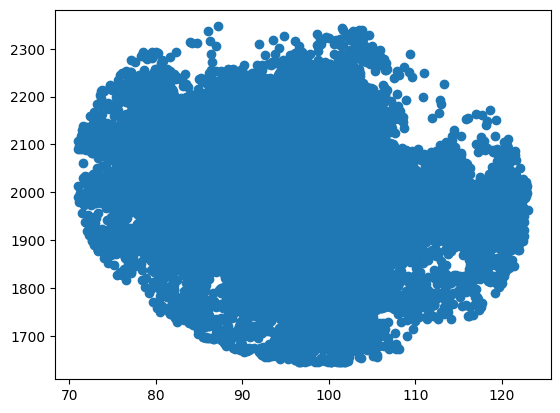

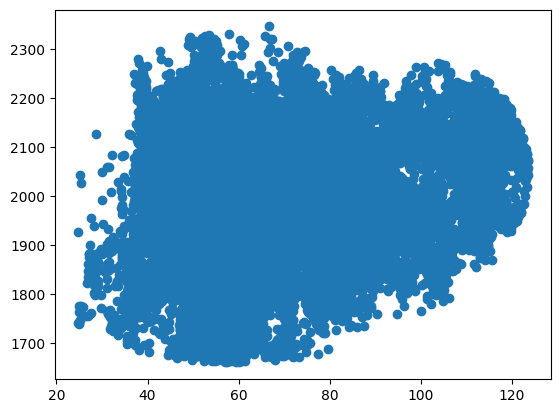

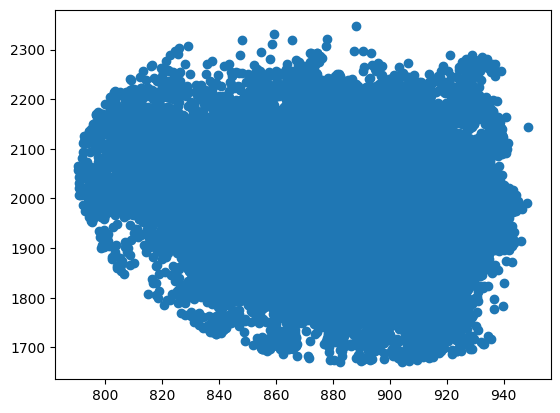

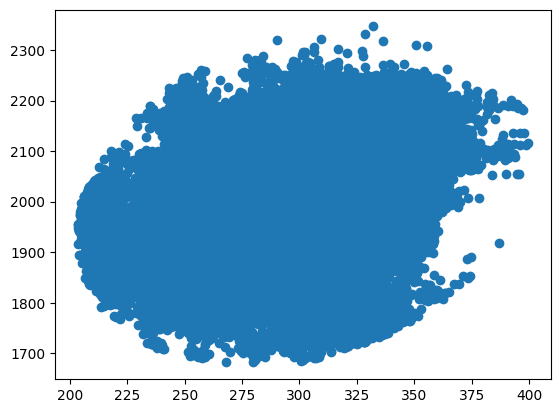

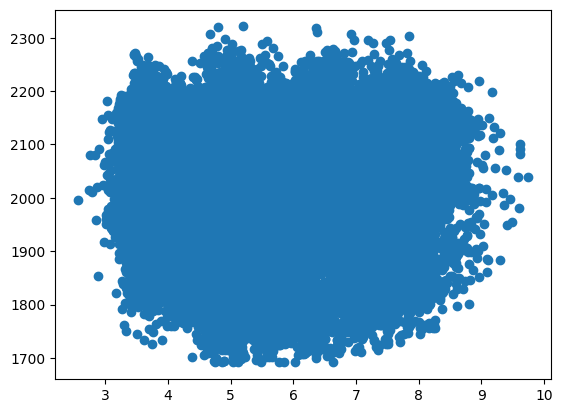

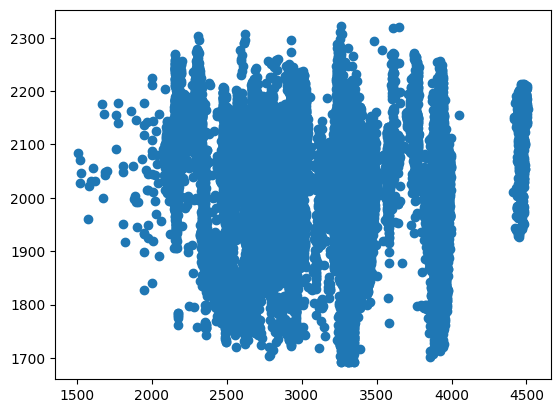

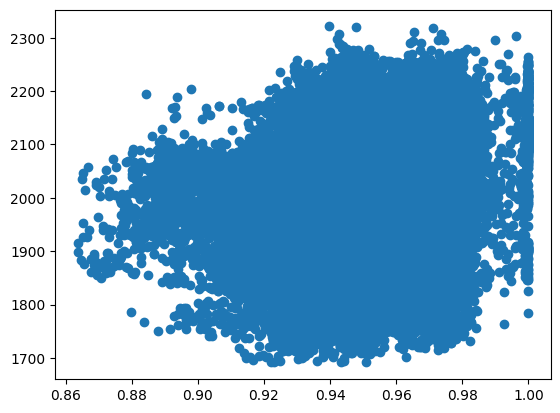

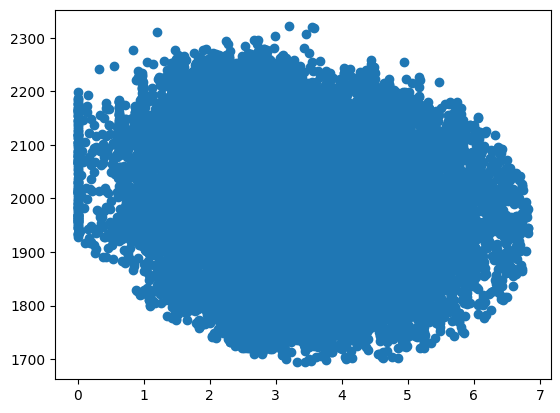

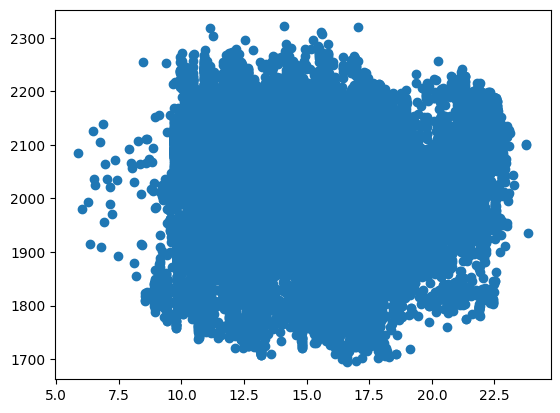

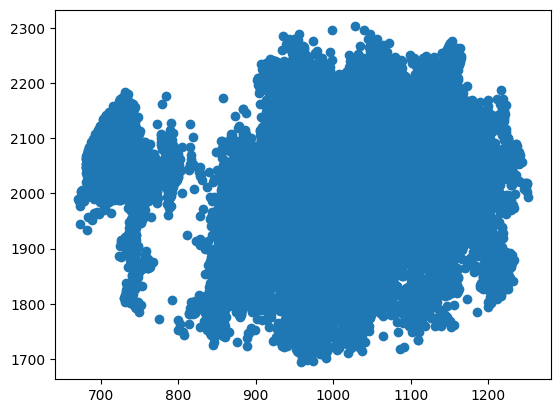

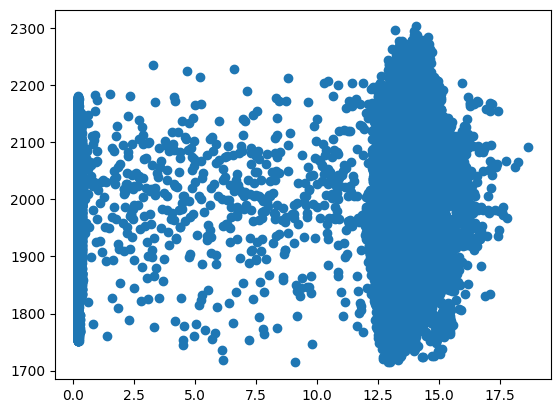

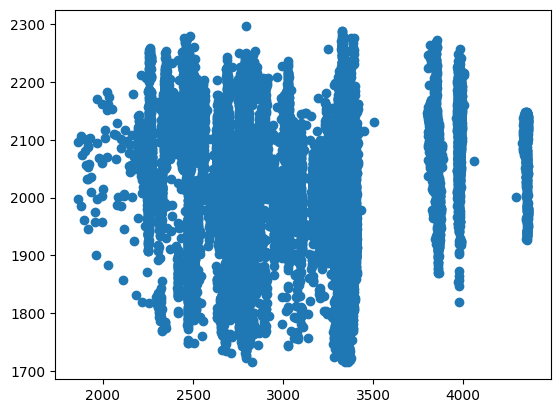

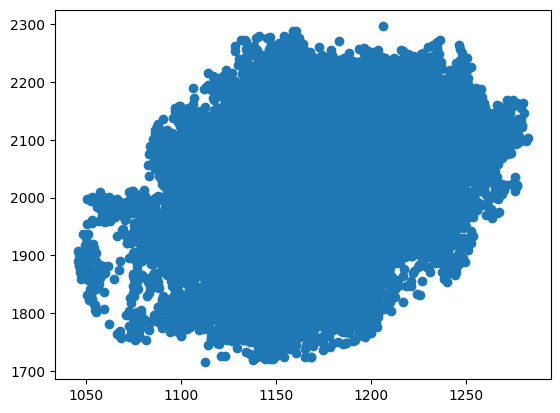

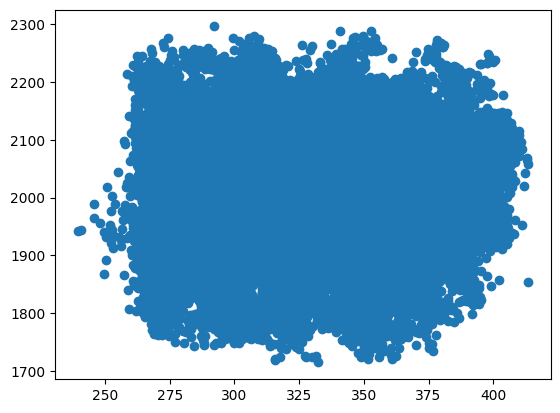

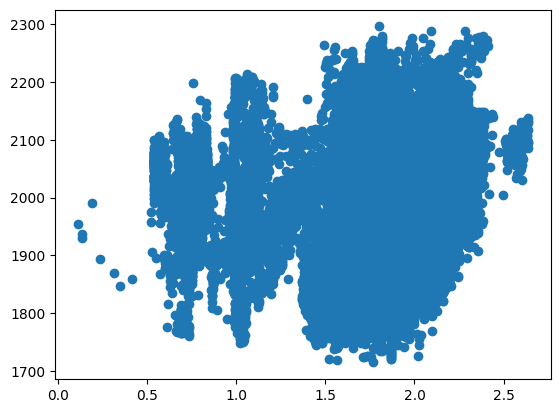

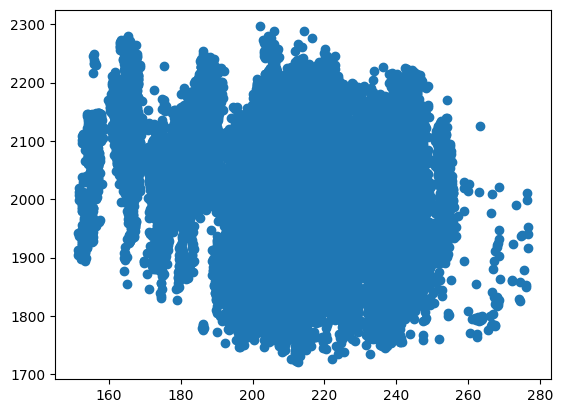

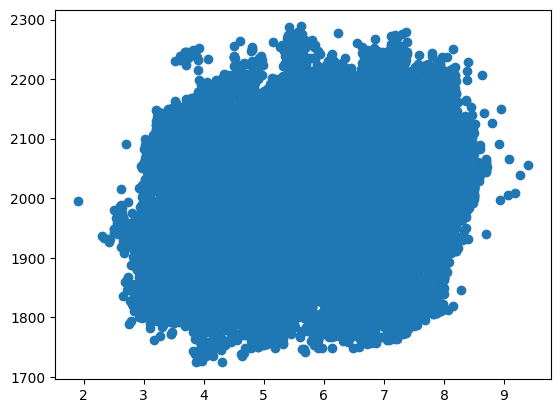

In [39]:
for i in features:
  data = data.loc[del_outliers_mahalanobis(data[[i,'前爐SOx濃度']]).index,:]
  plt.scatter(data[i],data['前爐SOx濃度'])
  plt.show()

# 標準化

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data.loc[:,features] = scaler.fit_transform(data.loc[:,features])
data

,MLUT4_ZT-231,MLUT4_AT-237,MLUT4_FT-232,MLUT4_FIC-231C,MLUT4_AIA792101A,MLUT4_FT-957,MLUT4_FT-792020,DeSOx_1st,鈣硫比,MLUT4_FIC-231A,...,MLUT4_FT-956,MLUT4_PDT-231,MLUT4_FQ-205,MLUT4_FT-V004,MLUT4_FT-951AB,MLUT4_PDT-232,MLUT4_FIC-233,MLUT4_AIA792101B,MLUT4_TE-251I,前爐SOx濃度
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-05 04:00:00,-0.535411,-1.595626,0.697094,1.103673,-1.652707,1.486920,1.557430,0.565673,-1.294963,1.465789,...,2.132552,1.321383,1.859733,-0.888734,-0.079289,2.868482,-2.226042,-1.354682,0.554406,2100.450661
2024-01-05 04:05:00,-0.535411,-1.592005,0.475506,1.138333,-1.642549,1.521102,1.555298,0.546847,-1.282167,1.465357,...,2.131892,1.480560,1.816349,1.309723,-0.099253,2.936733,-2.222979,-1.347338,0.564352,2071.450654
2024-01-05 04:10:00,-0.535411,-1.588385,0.571317,0.986589,-1.632391,1.496892,1.551028,0.604377,-1.301352,1.464925,...,2.130958,1.566300,1.806661,1.312123,-0.017228,2.925701,-2.213822,-1.339994,0.596541,2069.809665
2024-01-05 04:15:00,-0.535411,-1.584764,0.632562,0.969738,-1.622232,1.508813,1.549119,0.471036,-1.312128,1.464493,...,2.122692,1.707969,1.812795,1.314523,0.118630,2.935407,-2.207601,-1.332650,0.608778,2069.686020
2024-01-05 04:20:00,-0.535411,-1.581143,0.586004,1.153058,-1.612074,1.509481,1.547393,0.216147,-1.311802,1.464670,...,2.130381,1.734562,1.788545,1.316923,0.095377,2.991829,-2.211200,-1.325306,0.582180,2067.637705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,2.501002,0.317160,-1.841530,-0.365350,0.315509,-1.075494,-0.177224,-0.317958,0.693498,-0.668349,...,-1.186020,0.420807,-0.615174,0.294357,0.055806,-0.585250,0.826569,-0.369260,0.056390,2082.274527
2024-09-15 23:40:00,2.501002,0.251655,-1.893634,-0.371985,0.335665,-1.067199,-0.180736,-0.144006,0.692738,-0.667901,...,-1.168918,0.429849,-0.601691,0.294357,0.070470,-0.591705,0.817243,-0.349802,0.028183,2071.948976
2024-09-15 23:45:00,2.501002,0.316627,-1.800577,-0.365171,0.295549,-1.082805,-0.179698,-0.073031,0.693144,-0.667453,...,-1.173903,0.493330,-0.691269,0.294357,0.160499,-0.599188,0.831602,-0.305161,-0.004282,2088.339754


In [41]:
data.loc[:,features]

,MLUT4_ZT-231,MLUT4_AT-237,MLUT4_FIC-231C,MLUT4_FT-792020,MLUT4_FIC-231B,MLUT4_TE-252D,MLUT4_FT-951AB,MLUT4_PDT-232,MLUT4_TE-251I,MLUT4_FT-232,...,鈣硫比,MLUT4_FIC-231A,MLUT4_PIC-233,MLUT4_IT-E7925A,MLUT4_FT-956,MLUT4_PDT-231,MLUT4_FQ-205,MLUT4_FT-V004,MLUT4_FIC-233,MLUT4_AIA792101B
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-05 04:00:00,-0.535411,-1.595626,1.103673,1.557430,0.029907,-0.690690,-0.079289,2.868482,0.554406,0.697094,...,-1.294963,1.465789,1.107498,0.430718,2.132552,1.321383,1.859733,-0.888734,-2.226042,-1.354682
2024-01-05 04:05:00,-0.535411,-1.592005,1.138333,1.555298,0.029986,-0.707704,-0.099253,2.936733,0.564352,0.475506,...,-1.282167,1.465357,1.148608,0.440058,2.131892,1.480560,1.816349,1.309723,-2.222979,-1.347338
2024-01-05 04:10:00,-0.535411,-1.588385,0.986589,1.551028,0.030066,-0.651042,-0.017228,2.925701,0.596541,0.571317,...,-1.301352,1.464925,1.170170,0.442293,2.130958,1.566300,1.806661,1.312123,-2.213822,-1.339994
2024-01-05 04:15:00,-0.535411,-1.584764,0.969738,1.549119,0.030145,-0.689259,0.118630,2.935407,0.608778,0.632562,...,-1.312128,1.464493,1.204502,0.427728,2.122692,1.707969,1.812795,1.314523,-2.207601,-1.332650
2024-01-05 04:20:00,-0.535411,-1.581143,1.153058,1.547393,0.030224,-0.699240,0.095377,2.991829,0.582180,0.586004,...,-1.311802,1.464670,1.220778,0.435942,2.130381,1.734562,1.788545,1.316923,-2.211200,-1.325306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,2.501002,0.317160,-0.365350,-0.177224,0.490699,-0.042000,0.055806,-0.585250,0.056390,-1.841530,...,0.693498,-0.668349,-0.380774,0.249933,-1.186020,0.420807,-0.615174,0.294357,0.826569,-0.369260
2024-09-15 23:40:00,2.501002,0.251655,-0.371985,-0.180736,0.492418,-0.110295,0.070470,-0.591705,0.028183,-1.893634,...,0.692738,-0.667901,-0.360526,0.248914,-1.168918,0.429849,-0.601691,0.294357,0.817243,-0.349802
2024-09-15 23:45:00,2.501002,0.316627,-0.365171,-0.179698,0.496677,-0.141622,0.160499,-0.599188,-0.004282,-1.800577,...,0.693144,-0.667453,-0.338067,0.243860,-1.173903,0.493330,-0.691269,0.294357,0.831602,-0.305161


# 線性回歸

In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

X,Y = data[features],data['前爐SOx濃度']

# 2. 資料切分：訓練 80% / 測試 20%
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練線性回歸模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 預測
y_pred = model.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_reg = res
res_reg

,R2,RMSE,MAPE
0,0.834323,40.257507,1.406409


# Ridge 回歸

In [43]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 切分資料為訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 Ridge 回歸模型
ridge = Ridge(alpha=1.0)  # 可嘗試不同的 alpha，例如 0.1, 1, 10
ridge.fit(X_train, y_train)

# 4. 預測
y_pred = ridge.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_ridge = res
res_ridge


,R2,RMSE,MAPE
0,0.834327,40.257067,1.406572


# Lasso 回歸

In [44]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立 Lasso 模型並訓練
lasso = Lasso(alpha=0.1)  # alpha 越大，壓縮越強，更多係數會變 0
lasso.fit(X_train, y_train)

# 4. 預測
y_pred = lasso.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_lasso = res
res_lasso


,R2,RMSE,MAPE
0,0.834078,40.287244,1.412328


In [45]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立 ElasticNet 模型並訓練
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5 表示 L1:L2 = 1:1
elastic_net.fit(X_train, y_train)

# 4. 預測
y_pred = elastic_net.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_ElasticNet = res
res_ElasticNet


,R2,RMSE,MAPE
0,0.751291,49.324443,1.876563


In [46]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 訓練/測試資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 PLS 模型（選擇主成分數目）
pls = PLSRegression(n_components=2)
pls.fit(X_train, y_train)

# 4. 預測
y_pred = pls.predict(X_test).ravel()  # .ravel() 將輸出轉成一維陣列

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_PLS = res
res_PLS


,R2,RMSE,MAPE
0,0.384079,77.620905,3.113094


In [47]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from tqdm import tqdm

# 2. 訓練/測試資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=1, warm_start=True, random_state=42)
n_estimators = 100
for i in tqdm(range(1, n_estimators + 1)):
    rf.set_params(n_estimators=i)
    rf.fit(X_train, y_train)

# 4. 預測
y_pred = rf.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_rf = res
res_rf


100%|██████████| 100/100 [02:26<00:00,  1.46s/it]


,R2,RMSE,MAPE
0,0.94728,22.709311,0.67587


In [48]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 XGBoost 回歸模型
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# 4. 預測
y_pred = xgb.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_xgb = res
res_xgb


,R2,RMSE,MAPE
0,0.934305,25.350232,0.83116


In [49]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. 建立並訓練 SVR 模型
svr = SVR()
svr.fit(X_train,y_train)

# 5. 預測（記得反標準化）
y_pred = svr.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_svr = res
res_svr


,R2,RMSE,MAPE
0,0.747008,49.7473,1.830012


In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import numpy as np

# 切分資料
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 轉成Tensor
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# 2. 定義 MLP 模型
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=len(features))

# 3. 損失函數與優化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. 訓練迴圈
n_epochs = 300
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}")

# 5. 測試與評估
model.eval()
with torch.no_grad():
    y_pred_t = model(X_test_t).view(-1).numpy()

r2 = r2_score(y_test, y_pred_t)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_t))
mape = mean_absolute_percentage_error(y_test, y_pred_t)

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_mlp = res
res_mlp


Epoch [5/300], Loss: 4065689.7500
Epoch [10/300], Loss: 4040522.0000
Epoch [15/300], Loss: 3978964.7500
Epoch [20/300], Loss: 3856115.5000
Epoch [25/300], Loss: 3641680.0000
Epoch [30/300], Loss: 3304751.5000
Epoch [35/300], Loss: 2825021.0000
Epoch [40/300], Loss: 2213266.5000
Epoch [45/300], Loss: 1540703.8750
Epoch [50/300], Loss: 962453.0000
Epoch [55/300], Loss: 668563.1875
Epoch [60/300], Loss: 653787.4375
Epoch [65/300], Loss: 629044.0000
Epoch [70/300], Loss: 515467.3438
Epoch [75/300], Loss: 435133.0312
Epoch [80/300], Loss: 399815.4062
Epoch [85/300], Loss: 367457.7812
Epoch [90/300], Loss: 329421.9062
Epoch [95/300], Loss: 297623.2812
Epoch [100/300], Loss: 274791.0000
Epoch [105/300], Loss: 254598.2812
Epoch [110/300], Loss: 234922.3750
Epoch [115/300], Loss: 217560.5312
Epoch [120/300], Loss: 202492.6250
Epoch [125/300], Loss: 188717.1875
Epoch [130/300], Loss: 176037.4062
Epoch [135/300], Loss: 164532.5000
Epoch [140/300], Loss: 154024.8750
Epoch [145/300], Loss: 144380.1

,R2,RMSE,MAPE
0,-1.819076,166.061694,0.06452


In [51]:
res = pd.concat([res_reg,res_ridge,res_lasso,res_ElasticNet,res_PLS,res_rf,res_xgb,res_svr,res_mlp])
res.index = ['reg','ridge','lasso','elastic','PLS','rf','xgb','svr','mlp']
res

,R2,RMSE,MAPE
reg,0.834323,40.257507,1.406409
ridge,0.834327,40.257067,1.406572
lasso,0.834078,40.287244,1.412328
elastic,0.751291,49.324443,1.876563
PLS,0.384079,77.620905,3.113094
rf,0.947280,22.709311,0.675870
xgb,0.934305,25.350232,0.831160
svr,0.747008,49.747300,1.830012
mlp,-1.819076,166.061694,0.064520


<ipython-input-52-3284107390>:12: UserWarning: Glyph 37411 (\N{CJK UNIFIED IDEOGRAPH-9223}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-52-3284107390>:12: UserWarning: Glyph 30827 (\N{CJK UNIFIED IDEOGRAPH-786B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-52-3284107390>:12: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37411 (\N{CJK UNIFIED IDEOGRAPH-9223}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30827 (\N{CJK UNIFIED IDEOGRAPH-786B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font

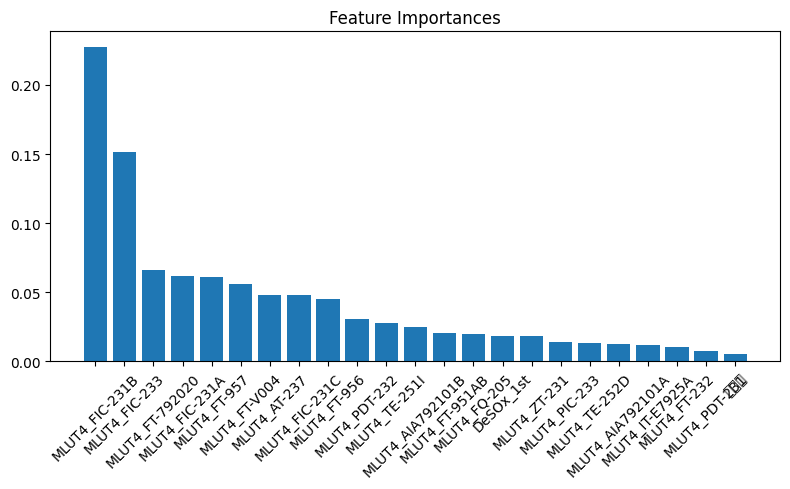

In [52]:
import matplotlib.pyplot as plt

# 排序特徵重要度
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 畫圖
plt.figure(figsize=(8, 5))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()
